In [87]:
import json
import pandas as pd

data_path_prefix = '../data_collection/data/processed/'
labels_file = data_path_prefix + 'label_vocab.json'
train_file = data_path_prefix + 'train.json'
val_file = data_path_prefix + 'val.json'
test_file = data_path_prefix + 'test.json'

with open(labels_file) as f:
    labels_json = json.load(f)
topics = labels_json['topic']
print(topics)

with open(train_file, 'r') as f:
    train_json = json.load(f)
train_df = pd.DataFrame(train_json)
train_df

['2d', '3d', 'animation', 'buildsystem', 'core', 'dotnet', 'editor', 'export', 'gdscript', 'gui', 'import', 'input', 'other', 'physics', 'platforms', 'rendering', 'shaders', 'thirdparty']


,id,title,body,created_at,issue_type,platform,impact,topic,text_raw,text_clean
0,1642259537,Typed arrays won't accept node references with $,### Godot version\r\n\r\n4.0.1\r\n\r\n### Syst...,2023-03-27T14:54:15+00:00,bug,[],[],[gdscript],Typed arrays won't accept node references with...,Typed arrays won't accept node references with...
1,1642389854,Inconsitent peer id type in C#,### Godot version\r\n\r\n4.0.1 stable mono win...,2023-03-27T16:05:35+00:00,bug,[],[],"[dotnet, other]",Inconsitent peer id type in C#\n\n### Godot ve...,Inconsitent peer id type in C# Godot version 4...
2,1642430924,Capsule CharacterBody3D gets stuck in small Co...,### Godot version\n\n4.0.1-stable\n\n### Syste...,2023-03-27T16:31:37+00:00,bug,[],[],"[physics, 3d]",Capsule CharacterBody3D gets stuck in small Co...,Capsule CharacterBody3D gets stuck in small Co...
3,1642496864,`Polygon2D` animations fail to interpolate bet...,### Godot version\r\n\r\n4.0\r\n\r\n### System...,2023-03-27T17:14:23+00:00,bug,[],[],[animation],`Polygon2D` animations fail to interpolate bet...,Polygon2D animations fail to interpolate betwe...
4,1642551545,One-line Labels with word wrapping add a lot o...,### Godot version\r\n\r\n4.0.1\r\n\r\n### Syst...,2023-03-27T17:55:46+00:00,bug,[],[],[gui],One-line Labels with word wrapping add a lot o...,One-line Labels with word wrapping add a lot o...
...,...,...,...,...,...,...,...,...,...,...
12722,2835396794,The finished signal of the AudioStreamPlayer s...,### Tested versions\nv4.5.dev3.official [55fc6...,2025-02-06T12:27:03+00:00,bug,[],[],[other],The finished signal of the AudioStreamPlayer s...,The finished signal of the AudioStreamPlayer s...
12723,2835433924,GDScript Editor Soft-Wrap Line Misaligns When ...,### Tested versions\n\nReproducible in v4.3.st...,2025-02-06T12:44:09+00:00,bug,[],[],"[editor, gui]",GDScript Editor Soft-Wrap Line Misaligns When ...,GDScript Editor Soft-Wrap Line Misaligns When ...
12724,2835459371,DPI setting is not taken into account upon win...,"### Tested versions\n\n4.4-beta2_mono, 4.3-sta...",2025-02-06T12:55:33+00:00,bug,[],[],[gui],DPI setting is not taken into account upon win...,DPI setting is not taken into account upon win...
12725,2835479473,.NET: Failed to unload assemblies when using `...,### Tested versions\n\nReproducible in 4.2.sta...,2025-02-06T13:04:07+00:00,bug,[],[],[dotnet],.NET: Failed to unload assemblies when using `...,.NET: Failed to unload assemblies when using T...


In [88]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,
)

X_train = tfidf.fit_transform(train_df["text_clean"].fillna(""))
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2601703 stored elements and shape (12727, 163315)>

In [89]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer(classes=topics)
Y_train = mlb.fit_transform(train_df['topic'])

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

clf = OneVsRestClassifier(
    LogisticRegression(
        max_iter=2000,
        n_jobs=1,
        class_weight='balanced'
    )
)

clf.fit(X_train, Y_train)

c:\Users\purpa\OneDrive\Desktop\Projects\godot-issue-triager\.venv_312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\purpa\OneDrive\Desktop\Projects\godot-issue-triager\.venv_312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\purpa\OneDrive\Desktop\Projects\godot-issue-triager\.venv_312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\purpa\OneDrive\Desktop\Projects\godot-issue-triager\.venv_312\Lib\site-packa

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.","LogisticRegre...000, n_jobs=1)"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', defaul

In [91]:
from sklearn.metrics import f1_score, classification_report, hamming_loss

with open(val_file, 'r') as f:
    val_json = json.load(f)

val_df = pd.DataFrame(val_json)

X_val = tfidf.transform(val_df['text_clean'].fillna(""))
Y_val = mlb.transform(val_df['topic'])

Y_pred = clf.predict(X_val)

results = [
    f1_score(Y_val, Y_pred, average="micro"),
    f1_score(Y_val, Y_pred, average="macro"),
    hamming_loss(Y_val, Y_pred),
    classification_report(Y_val, Y_pred, target_names=mlb.classes_)
]
print("micro F1:", results[0])
print("macro F1:", results[1])
print("hamming loss:", results[2])
print(results[3])

micro F1: 0.6697926059513075
macro F1: 0.6344631436540187
hamming loss: 0.05595281750397262
              precision    recall  f1-score   support

          2d       0.56      0.54      0.55        91
          3d       0.59      0.86      0.70       196
   animation       0.79      0.82      0.81        74
 buildsystem       0.74      0.78      0.76        40
        core       0.47      0.51      0.49       153
      dotnet       0.56      0.74      0.63        53
      editor       0.72      0.76      0.74       627
      export       0.39      0.81      0.53        37
    gdscript       0.57      0.76      0.65       140
         gui       0.67      0.75      0.70       269
      import       0.76      0.81      0.78        77
       input       0.52      0.68      0.59        87
       other       0.78      0.72      0.75       142
     physics       0.74      0.86      0.79        70
   platforms       0.31      0.59      0.40       118
   rendering       0.70      0.79      0.74

c:\Users\purpa\OneDrive\Desktop\Projects\godot-issue-triager\.venv_312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\purpa\OneDrive\Desktop\Projects\godot-issue-triager\.venv_312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\purpa\OneDrive\Desktop\Projects\godot-issue-triager\.venv_312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` para

In [92]:
import json, time
import numpy as np
from sklearn.metrics import f1_score, hamming_loss, precision_recall_fscore_support

def to_jsonable(x):
    # primitives
    if x is None or isinstance(x, (str, int, float, bool)):
        return x

    # numpy scalars/arrays
    if isinstance(x, (np.integer, np.floating)):
        return x.item()
    if isinstance(x, np.ndarray):
        return x.tolist()

    # containers
    if isinstance(x, dict):
        return {str(k): to_jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple, set)):
        return [to_jsonable(v) for v in x]

    # types (e.g., np.float64)
    if isinstance(x, type):
        return f"{x.__module__}.{x.__name__}"

    # sklearn estimators or other objects: store class name + shallow params if possible
    if hasattr(x, "get_params"):
        return {
            "__estimator__": x.__class__.__name__,
            "params": to_jsonable(x.get_params(deep=False))
        }

    # fallback
    return str(x)

run = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "tfidf_params": tfidf.get_params(),
    "model": "OneVsRest(LogisticRegression)",
    "model_params": clf.get_params(),
    "metrics": {
        "micro_f1": float(f1_score(Y_val, Y_pred, average="micro")),
        "macro_f1": float(f1_score(Y_val, Y_pred, average="macro")),
        "hamming_loss": float(hamming_loss(Y_val, Y_pred)),
    }
}

p, r, f1, sup = precision_recall_fscore_support(Y_val, Y_pred, average=None, zero_division=0)
run["per_label"] = [
    {"label": lab, "precision": float(pi), "recall": float(ri), "f1": float(fi), "support": int(si)}
    for lab, pi, ri, fi, si in zip(mlb.classes_, p, r, f1, sup)
]

with open("baseline_pretuning.json", "w") as f:
    json.dump(to_jsonable(run), f, indent=2)

print("Saved baseline_pretuning.json")

Saved baseline_pretuning.json


In [93]:
import numpy as np

proba = clf.predict_proba(X_val)  # shape: (N, K)

candidates = np.linspace(0.05, 0.95, 60)
rows = []

for t in candidates:
    Yp = (proba >= t).astype(int)
    rows.append((
        float(t),
        float(f1_score(Y_val, Yp, average="micro", zero_division=0)),
        float(f1_score(Y_val, Yp, average="macro", zero_division=0)),
        float(hamming_loss(Y_val, Yp)),
        float((Yp.sum(axis=1) > 0).mean()),
        float(Yp.sum(axis=1).mean()),
    ))

# pick best by micro (or macro)
best_micro = max(rows, key=lambda r: r[1])
best_macro = max(rows, key=lambda r: r[2])

best_micro, best_macro

((0.5228813559322034,
  0.6710182767624021,
  0.6375849332416293,
  0.0539053905390539,
  0.9075907590759076,
  1.5577557755775577),
 (0.5228813559322034,
  0.6710182767624021,
  0.6375849332416293,
  0.0539053905390539,
  0.9075907590759076,
  1.5577557755775577))

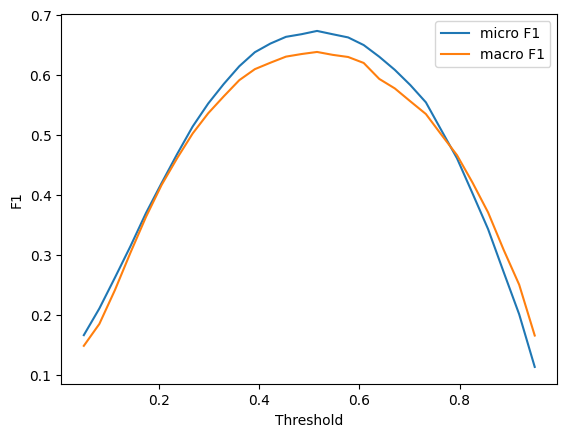

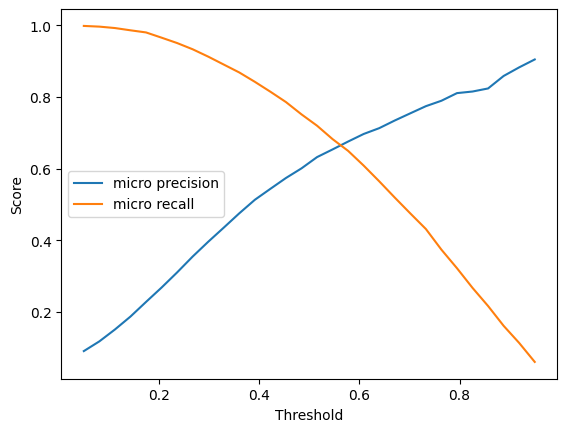

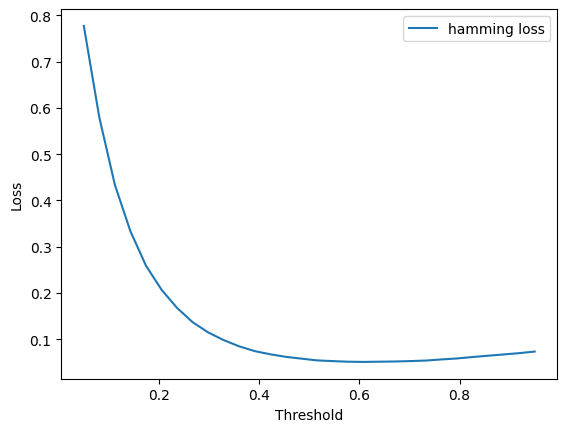

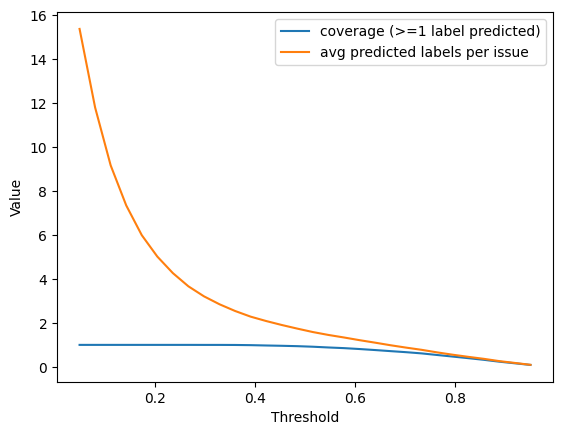

In [94]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, hamming_loss,
    precision_score, recall_score
)

# Make sure you have proba already:
# proba = clf.predict_proba(X_val)

candidates = np.linspace(0.05, 0.95, 30)

micro_f1s, macro_f1s, ham_losses = [], [], []
micro_ps, micro_rs = [], []
coverages, avg_labels = [], []

for t in candidates:
    Yp = (proba >= t).astype(int)

    micro_f1s.append(f1_score(Y_val, Yp, average="micro", zero_division=0))
    macro_f1s.append(f1_score(Y_val, Yp, average="macro", zero_division=0))
    ham_losses.append(hamming_loss(Y_val, Yp))

    micro_ps.append(precision_score(Y_val, Yp, average="micro", zero_division=0))
    micro_rs.append(recall_score(Y_val, Yp, average="micro", zero_division=0))

    coverages.append((Yp.sum(axis=1) > 0).mean())
    avg_labels.append(Yp.sum(axis=1).mean())

# 1) F1 vs threshold
plt.figure()
plt.plot(candidates, micro_f1s, label="micro F1")
plt.plot(candidates, macro_f1s, label="macro F1")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.legend()
plt.show()

# 2) Precision/Recall vs threshold
plt.figure()
plt.plot(candidates, micro_ps, label="micro precision")
plt.plot(candidates, micro_rs, label="micro recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

# 3) Hamming loss vs threshold
plt.figure()
plt.plot(candidates, ham_losses, label="hamming loss")
plt.xlabel("Threshold")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 4) Coverage & avg predicted labels vs threshold
plt.figure()
plt.plot(candidates, coverages, label="coverage (>=1 label predicted)")
plt.plot(candidates, avg_labels, label="avg predicted labels per issue")
plt.xlabel("Threshold")
plt.ylabel("Value")
plt.legend()
plt.show()

In [95]:
import numpy as np
from sklearn.metrics import f1_score

def fit_per_label_thresholds(proba, Y_true, grid=None):
    """
    proba: (N, K) predicted probabilities on *validation*
    Y_true: (N, K) multi-hot ground truth for validation
    returns: thresholds (K,), best_f1_per_label (K,)
    """
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)

    K = proba.shape[1]
    thresholds = np.full(K, 0.5, dtype=float)
    best_f1s = np.zeros(K, dtype=float)

    for j in range(K):
        best_t, best_f1 = 0.5, -1.0
        yj = Y_true[:, j]
        pj = proba[:, j]

        for t in grid:
            pred_j = (pj >= t).astype(int)
            f1 = f1_score(yj, pred_j, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t

        thresholds[j] = best_t
        best_f1s[j] = best_f1

    return thresholds, best_f1s

# Tune thresholds on validation
thresholds, best_f1s = fit_per_label_thresholds(proba, Y_val)
thresholds

array([0.45, 0.55, 0.45, 0.6 , 0.5 , 0.55, 0.45, 0.6 , 0.45, 0.55, 0.45,
       0.65, 0.55, 0.5 , 0.4 , 0.5 , 0.75, 0.4 ])

In [96]:
def predict_with_thresholds_and_abstain(proba, thresholds, class_names):
    """
    Returns:
      Y_pred: (N, K) multi-hot predictions
      abstain: (N,) bool
      pred_label_lists: list[list[str]]
      needs_human_triage: (N,) bool (same as abstain)
    """
    Y_pred = (proba >= thresholds).astype(int)
    abstain = (Y_pred.sum(axis=1) == 0)
    needs_human_triage = abstain.copy()

    pred_label_lists = []
    for i in range(Y_pred.shape[0]):
        idx = np.where(Y_pred[i] == 1)[0]
        pred_label_lists.append([class_names[j] for j in idx])

    return Y_pred, abstain, pred_label_lists, needs_human_triage

Y_pred_pl, abstain, pred_label_lists, needs_human_triage = predict_with_thresholds_and_abstain(
    proba=proba,
    thresholds=thresholds,
    class_names=list(mlb.classes_)
)

print("abstain_rate:", abstain.mean())
print("coverage:", 1.0 - abstain.mean())
print("avg_pred_labels:", Y_pred_pl.sum(axis=1).mean())

abstain_rate: 0.06435643564356436
coverage: 0.9356435643564356
avg_pred_labels: 1.7277227722772277


In [97]:
from sklearn.metrics import f1_score, hamming_loss

mask = ~abstain
print("coverage:", mask.mean())
print("micro F1 @ coverage:", f1_score(Y_val[mask], Y_pred_pl[mask], average="micro", zero_division=0))
print("macro F1 @ coverage:", f1_score(Y_val[mask], Y_pred_pl[mask], average="macro", zero_division=0))
print("hamming loss @ coverage:", hamming_loss(Y_val[mask], Y_pred_pl[mask]))

coverage: 0.9356435643564357
micro F1 @ coverage: 0.6884830952811426
macro F1 @ coverage: 0.667426558950588
hamming loss @ coverage: 0.05627408713828467


In [98]:
from sklearn.metrics import f1_score, hamming_loss

print("micro F1 (all):", f1_score(Y_val, Y_pred_pl, average="micro", zero_division=0))
print("macro F1 (all):", f1_score(Y_val, Y_pred_pl, average="macro", zero_division=0))
print("hamming loss (all):", hamming_loss(Y_val, Y_pred_pl))
print("coverage:", (Y_pred_pl.sum(axis=1) > 0).mean())

micro F1 (all): 0.671486510315641
macro F1 (all): 0.6499692607511957
hamming loss (all): 0.05693069306930693
coverage: 0.9356435643564357


In [101]:
import json
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, hamming_loss, classification_report

# ---- 1) Load test ----
with open(test_file, "r") as f:
    test_json = json.load(f)
test_df = pd.DataFrame(test_json)

# ---- 2) Transform (NO fitting here) ----
X_test = tfidf.transform(test_df["text_clean"].fillna(""))
Y_test = mlb.transform(test_df["topic"])

# ---- 3) Predict probabilities ----
proba_test = clf.predict_proba(X_test)  # (N, K)

# ---- 4) Choose ONE prediction policy ----
# A) Global threshold (if you want)
# t_best = 0.5228813559322034
# Y_pred_test = (proba_test >= t_best).astype(int)

# B) Per-label thresholds (if you tuned thresholds on validation)
Y_pred_test = (proba_test >= thresholds).astype(int)

# ---- 5) Abstain / triage flag ----
abstain_test = (Y_pred_test.sum(axis=1) == 0)
needs_human_triage_test = abstain_test.copy()
coverage_test = 1.0 - abstain_test.mean()

print("TEST coverage:", coverage_test, "abstain_rate:", abstain_test.mean())
print("TEST avg_pred_labels:", Y_pred_test.sum(axis=1).mean())

# ---- 6) Readable predicted label lists ----
class_names = list(mlb.classes_)
pred_topic_lists_test = [
    [class_names[j] for j in np.where(Y_pred_test[i] == 1)[0]]
    for i in range(Y_pred_test.shape[0])
]

# Optionally attach to df for inspection
test_df = test_df.copy()
test_df["pred_topics"] = pred_topic_lists_test
test_df["needs_human_triage"] = needs_human_triage_test

# ---- 7) Metrics on ALL test samples (abstain counts as predicting nothing) ----
print("\n=== TEST metrics (all samples) ===")
print("micro F1:", f1_score(Y_test, Y_pred_test, average="micro", zero_division=0))
print("macro F1:", f1_score(Y_test, Y_pred_test, average="macro", zero_division=0))
print("hamming loss:", hamming_loss(Y_test, Y_pred_test))
print(classification_report(Y_test, Y_pred_test, target_names=class_names, zero_division=0))

# ---- 8) Metrics @ coverage (only non-abstained samples) ----
mask = ~abstain_test
print("\n=== TEST metrics (@coverage) ===")
print("coverage:", mask.mean())
print("micro F1 @ coverage:", f1_score(Y_test[mask], Y_pred_test[mask], average="micro", zero_division=0))
print("macro F1 @ coverage:", f1_score(Y_test[mask], Y_pred_test[mask], average="macro", zero_division=0))
print("hamming loss @ coverage:", hamming_loss(Y_test[mask], Y_pred_test[mask]))

import numpy as np

def topk_hit_rate(proba, Y_true, k=5, exclude_true_zero_label_rows=True):
    """
    proba: (N, K) predicted probabilities
    Y_true: (N, K) multi-hot ground truth
    Hit@k = fraction of rows where any true label appears in the top-k predicted labels.
    """
    if exclude_true_zero_label_rows:
        mask = (Y_true.sum(axis=1) > 0)
        proba = proba[mask]
        Y_true = Y_true[mask]

    # indices of top-k probs per row (unordered within top-k, which is fine for hit rate)
    topk_idx = np.argpartition(-proba, kth=k-1, axis=1)[:, :k]  # (N, k)

    # check if any of those indices is a true label (==1)
    rows = np.arange(Y_true.shape[0])[:, None]                  # (N, 1)
    hits = (Y_true[rows, topk_idx] == 1).any(axis=1)            # (N,)

    return hits.mean()

# examples:
print("Hit@1:", topk_hit_rate(proba_test, Y_test, k=1))
print("Hit@3:", topk_hit_rate(proba_test, Y_test, k=3))
print("Hit@5:", topk_hit_rate(proba_test, Y_test, k=5))

TEST coverage: 0.9496838053340665 abstain_rate: 0.05031619466593346
TEST avg_pred_labels: 1.7470442672532307

=== TEST metrics (all samples) ===
micro F1: 0.6687181290662916
macro F1: 0.6431721720469734
hamming loss: 0.0575565942626707
              precision    recall  f1-score   support

          2d       0.56      0.72      0.63       181
          3d       0.69      0.74      0.71       449
   animation       0.84      0.85      0.84       190
 buildsystem       0.78      0.65      0.71        78
        core       0.46      0.57      0.51       281
      dotnet       0.63      0.82      0.71        98
      editor       0.72      0.82      0.77      1358
      export       0.48      0.82      0.60        83
    gdscript       0.54      0.76      0.63       241
         gui       0.47      0.79      0.59       373
      import       0.68      0.84      0.75       129
       input       0.62      0.61      0.62       154
       other       0.81      0.66      0.73       302
     ph

In [100]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

def fit_thresholds_min_precision(
    proba_val: np.ndarray,
    Y_val: np.ndarray,
    class_names=None,
    min_precision: float = 0.70,
    grid=None,
    fallback: str = "max_f1",  # "max_f1" or "max_precision" or "fixed"
    fixed_fallback_t: float = 0.5,
    min_positives: int = 20,
):
    """
    Choose per-label thresholds on VALIDATION so that precision >= min_precision when possible.
    Among thresholds meeting the precision constraint, pick the one with highest recall.
    Fallback for labels that cannot meet the constraint or have too few positives.

    Returns:
      thresholds: (K,)
      summary: list[dict] per label with chosen threshold + achieved metrics
    """
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)

    N, K = proba_val.shape
    thresholds = np.full(K, fixed_fallback_t, dtype=float)
    summary = []

    for j in range(K):
        y_true = Y_val[:, j].astype(int)
        p = proba_val[:, j]
        pos = int(y_true.sum())

        # If too few positives, threshold selection will be noisy; fallback
        if pos < min_positives:
            # Choose fallback threshold based on preference
            if fallback == "fixed":
                t_star = fixed_fallback_t
            elif fallback == "max_precision":
                # pick t that maximizes precision (ties -> higher recall)
                best = (-1.0, -1.0, fixed_fallback_t)  # (precision, recall, t)
                for t in grid:
                    y_pred = (p >= t).astype(int)
                    prec = precision_score(y_true, y_pred, zero_division=0)
                    rec = recall_score(y_true, y_pred, zero_division=0)
                    if (prec > best[0]) or (prec == best[0] and rec > best[1]):
                        best = (prec, rec, t)
                t_star = best[2]
            else:  # "max_f1"
                best = (-1.0, fixed_fallback_t)  # (f1, t)
                for t in grid:
                    y_pred = (p >= t).astype(int)
                    f1 = f1_score(y_true, y_pred, zero_division=0)
                    if f1 > best[0]:
                        best = (f1, t)
                t_star = best[1]

            thresholds[j] = t_star
            y_pred_star = (p >= t_star).astype(int)
            prec_star = precision_score(y_true, y_pred_star, zero_division=0)
            rec_star = recall_score(y_true, y_pred_star, zero_division=0)
            f1_star = f1_score(y_true, y_pred_star, zero_division=0)

            summary.append({
                "label": class_names[j] if class_names is not None else j,
                "positives_val": pos,
                "threshold": float(t_star),
                "precision": float(prec_star),
                "recall": float(rec_star),
                "f1": float(f1_star),
                "met_min_precision": bool(prec_star >= min_precision),
                "note": f"fallback({fallback}) - low_support<{min_positives}"
            })
            continue

        # First, find thresholds meeting the min_precision constraint
        candidates = []
        for t in grid:
            y_pred = (p >= t).astype(int)
            prec = precision_score(y_true, y_pred, zero_division=0)
            if prec >= min_precision:
                rec = recall_score(y_true, y_pred, zero_division=0)
                f1 = f1_score(y_true, y_pred, zero_division=0)
                candidates.append((rec, f1, prec, t))

        if candidates:
            # pick highest recall (ties: higher F1, then higher precision)
            candidates.sort(key=lambda x: (x[0], x[1], x[2]), reverse=True)
            rec_star, f1_star, prec_star, t_star = candidates[0]
            note = "min_precision_met"
        else:
            # can't meet precision constraint -> fallback
            if fallback == "fixed":
                t_star = fixed_fallback_t
            elif fallback == "max_precision":
                best = (-1.0, -1.0, fixed_fallback_t)  # (precision, recall, t)
                for t in grid:
                    y_pred = (p >= t).astype(int)
                    prec = precision_score(y_true, y_pred, zero_division=0)
                    rec = recall_score(y_true, y_pred, zero_division=0)
                    if (prec > best[0]) or (prec == best[0] and rec > best[1]):
                        best = (prec, rec, t)
                t_star = best[2]
            else:  # "max_f1"
                best = (-1.0, fixed_fallback_t)  # (f1, t)
                for t in grid:
                    y_pred = (p >= t).astype(int)
                    f1 = f1_score(y_true, y_pred, zero_division=0)
                    if f1 > best[0]:
                        best = (f1, t)
                t_star = best[1]
            note = f"fallback({fallback}) - cannot_meet_min_precision"

        thresholds[j] = float(t_star)
        y_pred_star = (p >= t_star).astype(int)
        prec_star = precision_score(y_true, y_pred_star, zero_division=0)
        rec_star = recall_score(y_true, y_pred_star, zero_division=0)
        f1_star = f1_score(y_true, y_pred_star, zero_division=0)

        summary.append({
            "label": class_names[j] if class_names is not None else j,
            "positives_val": pos,
            "threshold": float(t_star),
            "precision": float(prec_star),
            "recall": float(rec_star),
            "f1": float(f1_star),
            "met_min_precision": bool(prec_star >= min_precision),
            "note": note
        })

    return thresholds, summary


def predict_with_thresholds_abstain_readable(
    proba: np.ndarray,
    thresholds: np.ndarray,
    class_names,
):
    """
    Apply per-label thresholds, return multi-hot predictions, abstain mask, readable label lists, triage flags.
    """
    Y_pred = (proba >= thresholds).astype(int)
    abstain = (Y_pred.sum(axis=1) == 0)
    needs_human_triage = abstain.copy()

    pred_label_lists = [
        [class_names[j] for j in np.where(Y_pred[i] == 1)[0]]
        for i in range(Y_pred.shape[0])
    ]
    return Y_pred, abstain, pred_label_lists, needs_human_triage


# ---- USAGE ----
# 1) Fit thresholds on VALIDATION ONLY
# proba_val = clf.predict_proba(X_val)
class_names = list(mlb.classes_)

thresholds_prec, summary = fit_thresholds_min_precision(
    proba_val=proba,
    Y_val=Y_val,
    class_names=class_names,
    min_precision=0.70,     # adjust to be stricter/looser
    grid=np.linspace(0.05, 0.95, 19),
    fallback="max_f1",      # reasonable default
    min_positives=20
)

# Optional: inspect which labels can/can't meet precision target
# print([s for s in summary if not s["met_min_precision"]][:5])

# 2) Apply to TEST (no refit!)
# proba_test = clf.predict_proba(X_test)
Y_pred_test, abstain_test, pred_topics_test, needs_triage_test = predict_with_thresholds_abstain_readable(
    proba=proba_test,
    thresholds=thresholds_prec,
    class_names=class_names
)

# 3) Evaluate
from sklearn.metrics import f1_score, hamming_loss, classification_report

print("coverage:", (~abstain_test).mean())
print("avg_pred_labels:", Y_pred_test.sum(axis=1).mean())
print("micro F1 (all):", f1_score(Y_test, Y_pred_test, average="micro", zero_division=0))
print("macro F1 (all):", f1_score(Y_test, Y_pred_test, average="macro", zero_division=0))
print("hamming loss (all):", hamming_loss(Y_test, Y_pred_test))
print(classification_report(Y_test, Y_pred_test, target_names=class_names, zero_division=0))

coverage: 0.896618091833929
avg_pred_labels: 1.4388232059389607
micro F1 (all): 0.648980786111382
macro F1 (all): 0.6053491933399365
hamming loss (all): 0.054975101579445816
              precision    recall  f1-score   support

          2d       0.81      0.42      0.55       181
          3d       0.83      0.44      0.58       449
   animation       0.81      0.94      0.87       190
 buildsystem       0.74      0.72      0.73        78
        core       0.60      0.20      0.29       281
      dotnet       0.67      0.74      0.71        98
      editor       0.75      0.77      0.76      1358
      export       0.61      0.30      0.40        83
    gdscript       0.74      0.44      0.55       241
         gui       0.47      0.79      0.59       373
      import       0.68      0.84      0.75       129
       input       0.68      0.49      0.57       154
       other       0.75      0.78      0.76       302
     physics       0.77      0.85      0.81       139
   platforms   

In [ ]:
def recall_at_k(proba, Y_true, k=5, exclude_true_zero_label_rows=True, average="micro"):
    """
    Multi-label Recall@k.

    average="micro": total true labels recovered in top-k / total true labels
    average="macro": mean over samples of (recovered true labels / true labels in sample)
                     (samples with 0 true labels are excluded if exclude_true_zero_label_rows=True)
    """
    if exclude_true_zero_label_rows:
        mask = (Y_true.sum(axis=1) > 0)
        proba = proba[mask]
        Y_true = Y_true[mask]

    # top-k label indices per row
    topk_idx = np.argpartition(-proba, kth=k-1, axis=1)[:, :k]  # (N, k)

    rows = np.arange(Y_true.shape[0])[:, None]
    hits = (Y_true[rows, topk_idx] == 1).astype(int)            # (N, k)
    recovered_per_row = hits.sum(axis=1)                         # (# true labels found in top-k per sample)
    true_per_row = Y_true.sum(axis=1)                            # (# true labels per sample)

    if average == "micro":
        return float(recovered_per_row.sum() / true_per_row.sum())
    elif average == "macro":
        return float(np.mean(recovered_per_row / true_per_row))
    else:
        raise ValueError("average must be 'micro' or 'macro'")

# examples
print("Recall@1 (micro):", recall_at_k(proba_test, Y_test, k=1, average="micro"))
print("Recall@3 (micro):", recall_at_k(proba_test, Y_test, k=3, average="micro"))
print("Recall@5 (micro):", recall_at_k(proba_test, Y_test, k=5, average="micro"))

print("Recall@3 (macro):", recall_at_k(proba_test, Y_test, k=3, average="macro"))

Recall@1 (micro): 0.5278884462151394
Recall@3 (micro): 0.8886454183266932
Recall@5 (micro): 0.9605577689243028
Recall@3 (macro): 0.9030307275614083
